In [5]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li, div.text_cell_render p{width:95% !important;font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
table td, th{font-size:16px;}
table{ margin-left:0 !important;   /* 왼쪽 여백 0 */}
</style>
"""))

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (사용 환경에 맞게 주석 해제)
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

# 1. CSV 파일 불러오기
file_path = r'C:\data\따릉이 데이터\20\2007_merge.csv'

try:
    # 공공자전거 데이터는 대개 cp949 또는 utf-8 인코딩을 사용합니다.
    df = pd.read_csv(file_path, encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='utf-8')

# 데이터 구조 확인용 출력
print("\n--- 컬럼 목록 ---")
print(df.columns)
df.head(10)


--- 컬럼 목록 ---
Index(['대여일시', '대여 대여소명', '반납일시', '반납 대여소명', '대여자치구', '반납 자치구', '대여요일'], dtype='object')


,대여일시,대여 대여소명,반납일시,반납 대여소명,대여자치구,반납 자치구,대여요일
0,2020-07-01 00:00:15,동대문중 교차로,2020-07-01 00:03:23,동대문롯데캐슬아파트 앞,동대문구,동대문구,수
1,2020-07-01 00:01:02,서울숲리버뷰자이APT105동 앞,2020-07-01 00:04:15,응봉역 1번출구,성동구,성동구,수
2,2020-07-01 00:01:26,성내어울터,2020-07-01 00:04:41,포레스 주상복합 빌딩,강동구,강동구,수
3,2020-07-01 00:03:41,도봉운전면허시험장 버스정류장 옆,2020-07-01 00:06:20,노원역7번출구,노원구,노원구,수
4,2020-07-01 00:03:08,공릉1단지아파트,2020-07-01 00:06:48,공릉역 1번 출구 앞,노원구,노원구,수
5,2020-07-01 00:01:35,돈암초교 입구,2020-07-01 00:07:45,홍익중고 입구,성북구,성북구,수
6,2020-07-01 00:04:38,용산 선인상가,2020-07-01 00:08:06,신용산역 6번출구 앞,용산구,용산구,수
7,2020-07-01 00:00:02,교대역 5번출구뒤,2020-07-01 00:08:06,서초역 3번출구,서초구,서초구,수
8,2020-07-01 00:04:37,서울남부터미널 대합실 입구,2020-07-01 00:08:38,서초역 3번출구,서초구,서초구,수
9,2020-07-01 00:00:23,용마사거리,2020-07-01 00:08:44,중곡 성원아파트 앞,광진구,광진구,수


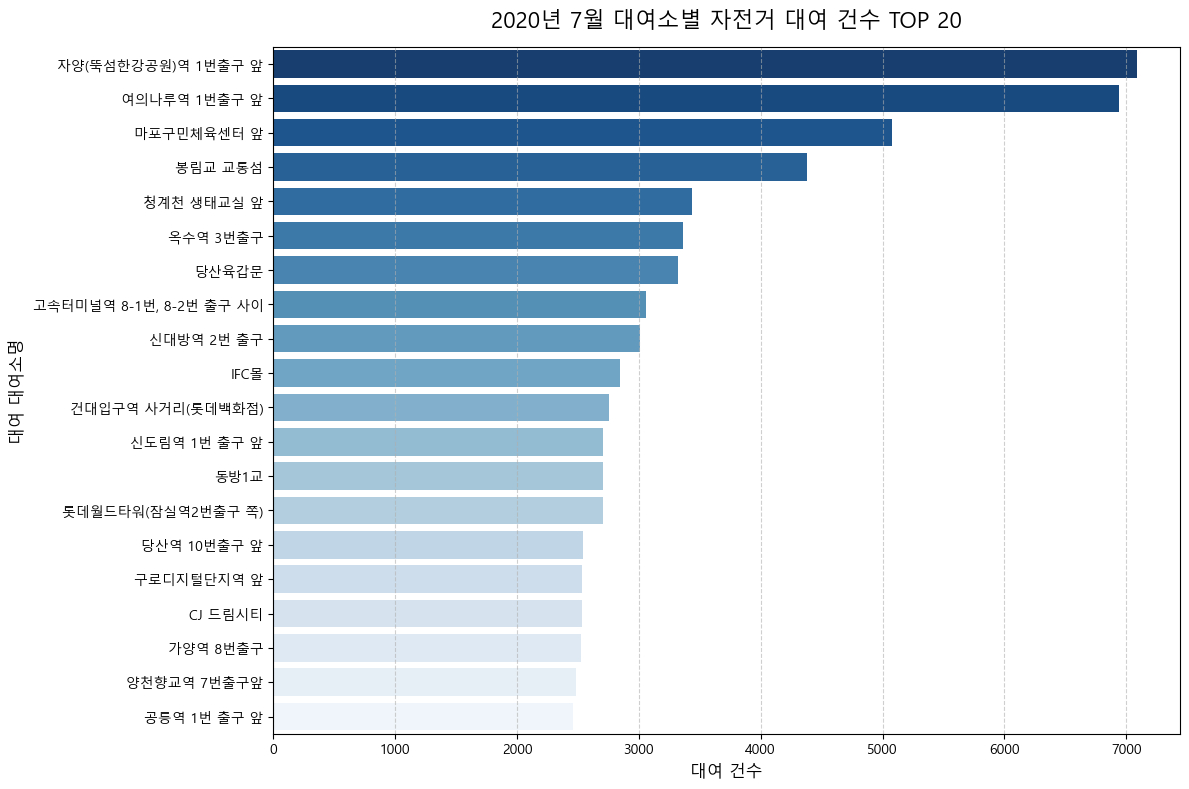

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. 대여소명 별 자전거 대여 건수 집계

station_counts = df['대여 대여소명'].value_counts().reset_index()
station_counts.columns = ['대여 대여소명', '대여건수']

# 3. 대여량이 가장 많은 상위 30개 대여소 추출 (전체를 그리면 글자가 겹칠 수 있습니다)
top_n = 20
top_stations = station_counts.head(top_n)

# 4. 대여소별 대여 수 수평 막대 그래프 시각화
plt.figure(figsize=(12, 8))
sns.barplot(data=top_stations, y='대여 대여소명', x='대여건수', palette='Blues_r')

plt.title(f'2020년 7월 대여소별 자전거 대여 건수 TOP {top_n}', fontsize=16, pad=15)
plt.xlabel('대여 건수', fontsize=12)
plt.ylabel('대여 대여소명', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# 고화질 이미지로 저장
plt.savefig('top_stations_rental_counts.png', dpi=300)
plt.show()

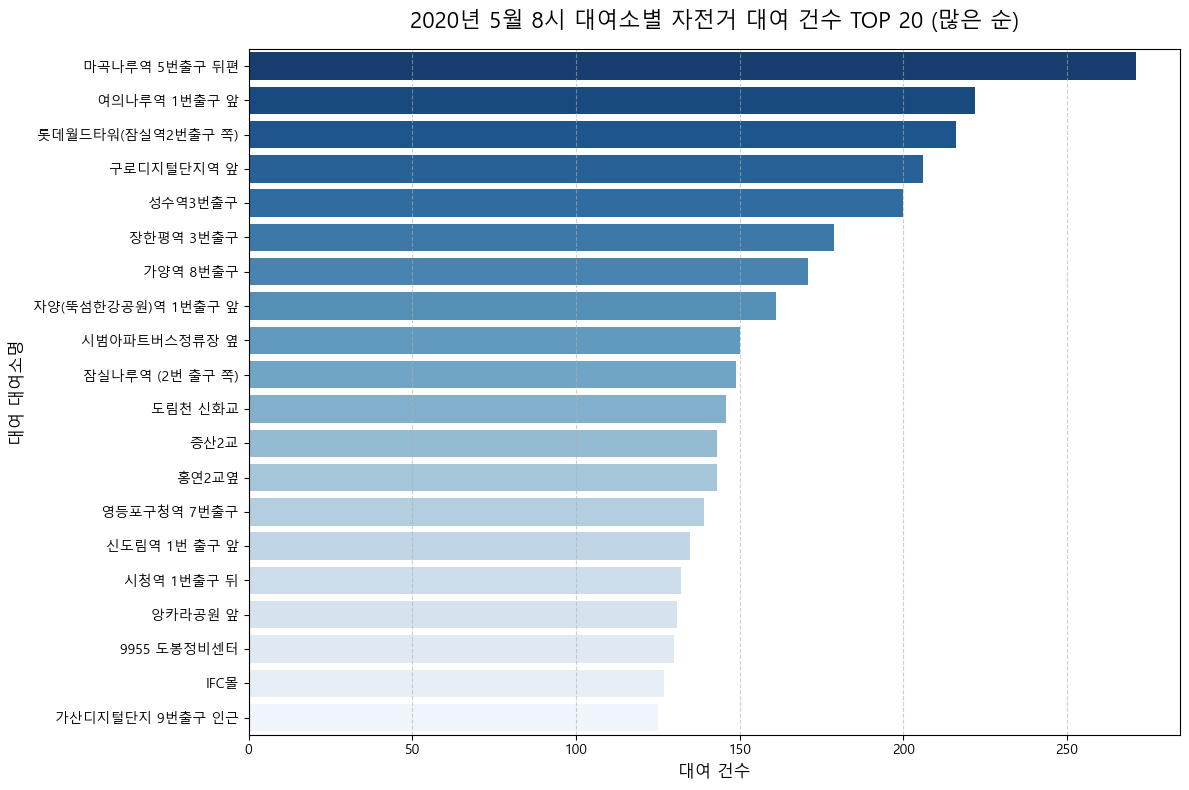

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 파일 불러오기 및 전처리
file_path = r'C:\data\따릉이 데이터\20\2007_merge.csv'
try:
    df = pd.read_csv(file_path, encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='utf-8')

df['대여일시'] = pd.to_datetime(df['대여일시'])
df['대여시간'] = df['대여일시'].dt.hour

# 2. 시간대별, 대여소별 대여 건수 집계
hourly_station_counts = df.groupby(['대여시간', '대여 대여소명']).size().reset_index(name='대여건수')

# 3. 시간대별 상위 20개 추출
top20_per_hour = hourly_station_counts.groupby('대여시간', group_keys=False).apply(
    lambda x: x.nlargest(20, '대여건수')
)

# 4. 특정 시간대(예: 8시) 선택
target_hour = 8

# [핵심] 대여건수가 많은 순서대로 위쪽에 오도록 정렬 (ascending=True 시 가장 큰 값이 맨 위로 감)
df_hour = top20_per_hour[top20_per_hour['대여시간'] == target_hour].sort_values(by='대여건수', ascending=False)
df_hour.iloc[::-1]
# 5. 시각화
plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_hour, 
    y='대여 대여소명', 
    x='대여건수', 
    palette='Blues_r'
)

plt.title(f'2020년 5월 {target_hour}시 대여소별 자전거 대여 건수 TOP 20 (많은 순)', fontsize=16, pad=15)
plt.xlabel('대여 건수', fontsize=12)
plt.ylabel('대여 대여소명', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig(f'top_stations_rental_counts_{target_hour}h.png', dpi=300)
plt.show()